# Primera Pre-Entrega: Aprendizaje de Máquina - UIS
**Estudiantes:** Juan José Rangel, Mateo Leyva e Isabella Plata

**Análisis Exploratorio y Curación de Datos (EDA)**

---
## Introducción
Este Notebook documenta el proceso de limpieza, transformación y análisis de un dataset de vehículos usados. El objetivo es preparar el espacio de características (*feature space*) para modelos de regresión que predigan el precio (`Price`).

## Fase 0: Pipeline de Curación de Datos
Para garantizar la **reproducibilidad** y la calidad del modelo (*Garbage In, Garbage Out*), ejecutamos un pipeline que transforma los datos crudos en tensores numéricos:
1. **Limpieza de Unidades:** Remoción de sufijos ('kmpl', 'CC', 'bhp') y casteo a `float`.
2. **Tratamiento de Nulidad:** Eliminación de variables con >40% de nulos e imputación por mediana.
3. **Codificación:** Factorización de variables categóricas para representación vectorial.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética global
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Carga de datos crudos
df_raw = pd.read_csv('used_cars_data.csv')

# 2. Curación inicial
df = df_raw.drop(columns=['S.No.', 'New_Price'], errors='ignore')

def clean_units(val):
    if pd.isna(val): return np.nan
    num = ''.join([c for c in str(val) if c.isdigit() or c == '.'])
    return float(num) if num else np.nan

for col in ['Mileage', 'Engine', 'Power']:
    df[col] = df[col].apply(clean_units)

# 3. Imputación técnica (Mediana)
for col in ['Mileage', 'Engine', 'Power', 'Seats', 'Price']:
    df[col] = df[col].fillna(df[col].median())

# 4. Factorización (Encoding)
categorical_cols = ['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']
for col in categorical_cols:
    df[col], _ = pd.factorize(df[col])

print("Pipeline de curación completado. Dataset listo para análisis.")

Pipeline de curación completado. Dataset listo para análisis.


## Fase 1: Inspección de Dimensionalidad
Verificamos la topología del dataset para asegurar que el volumen de observaciones sea suficiente para evitar el sobreajuste (*overfitting*).

In [22]:
print(f"Estructura del dataset (Rows, Cols): {df.shape}")
print(f"Lista de Features: {list(df.columns)}")
display(df.head(5))

Estructura del dataset (Rows, Cols): (7253, 12)
Lista de Features: ['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0.0,0.0,2010.0,72000.0,0.0,0.0,0.0,26.60,998.0,58.16,5.0,1.75
1,1.0,1.0,2015.0,41000.0,1.0,0.0,0.0,19.67,1582.0,126.20,5.0,12.50
2,2.0,2.0,2011.0,46000.0,2.0,0.0,0.0,18.20,1199.0,88.70,5.0,4.50
3,3.0,2.0,2012.0,87000.0,1.0,0.0,0.0,20.77,1248.0,88.76,7.0,6.00
4,4.0,3.0,2013.0,40670.0,1.0,1.0,1.0,15.20,1968.0,140.80,5.0,17.74


## Fase 2: Análisis de Medidas de Tendencia Central y Dispersión
Evaluamos las escalas de las variables a continuación.

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Name,7253.0,653.453192,533.415489,0.00,210.00,501.00,997.00,2040.00
Location,7253.0,4.337791,3.000975,0.00,2.00,4.00,7.00,10.00
Year,7253.0,2013.365366,3.254421,1996.00,2011.00,2014.00,2016.00,2019.00
Kilometers_Driven,7253.0,58699.063146,84427.720583,171.00,34000.00,53416.00,73000.00,6500000.00
Fuel_Type,7253.0,1.454019,0.519599,0.00,1.00,1.00,2.00,4.00
Transmission,7253.0,0.282504,0.450248,0.00,0.00,0.00,1.00,1.00
Owner_Type,7253.0,0.218806,0.536294,0.00,0.00,0.00,0.00,3.00
Mileage,7253.0,18.141586,4.561567,0.00,15.17,18.16,21.10,33.54
Engine,7253.0,1615.789742,593.475257,72.00,1198.00,1493.00,1968.00,5998.00
Power,7253.0,112.312448,52.922581,34.20,77.00,94.00,138.03,616.00


## Fase 3: Detección de Valores Atípicos (IQR)
Utilizamos el **Rango Intercuartílico ($IQR = Q3 - Q1$)** para detectar anomalías. Puntos fuera de $[Q1 - 1.5 \cdot IQR, Q3 + 1.5 \cdot IQR]$ representan vehículos de alta gama o errores que podrían sesgar la función de pérdida.

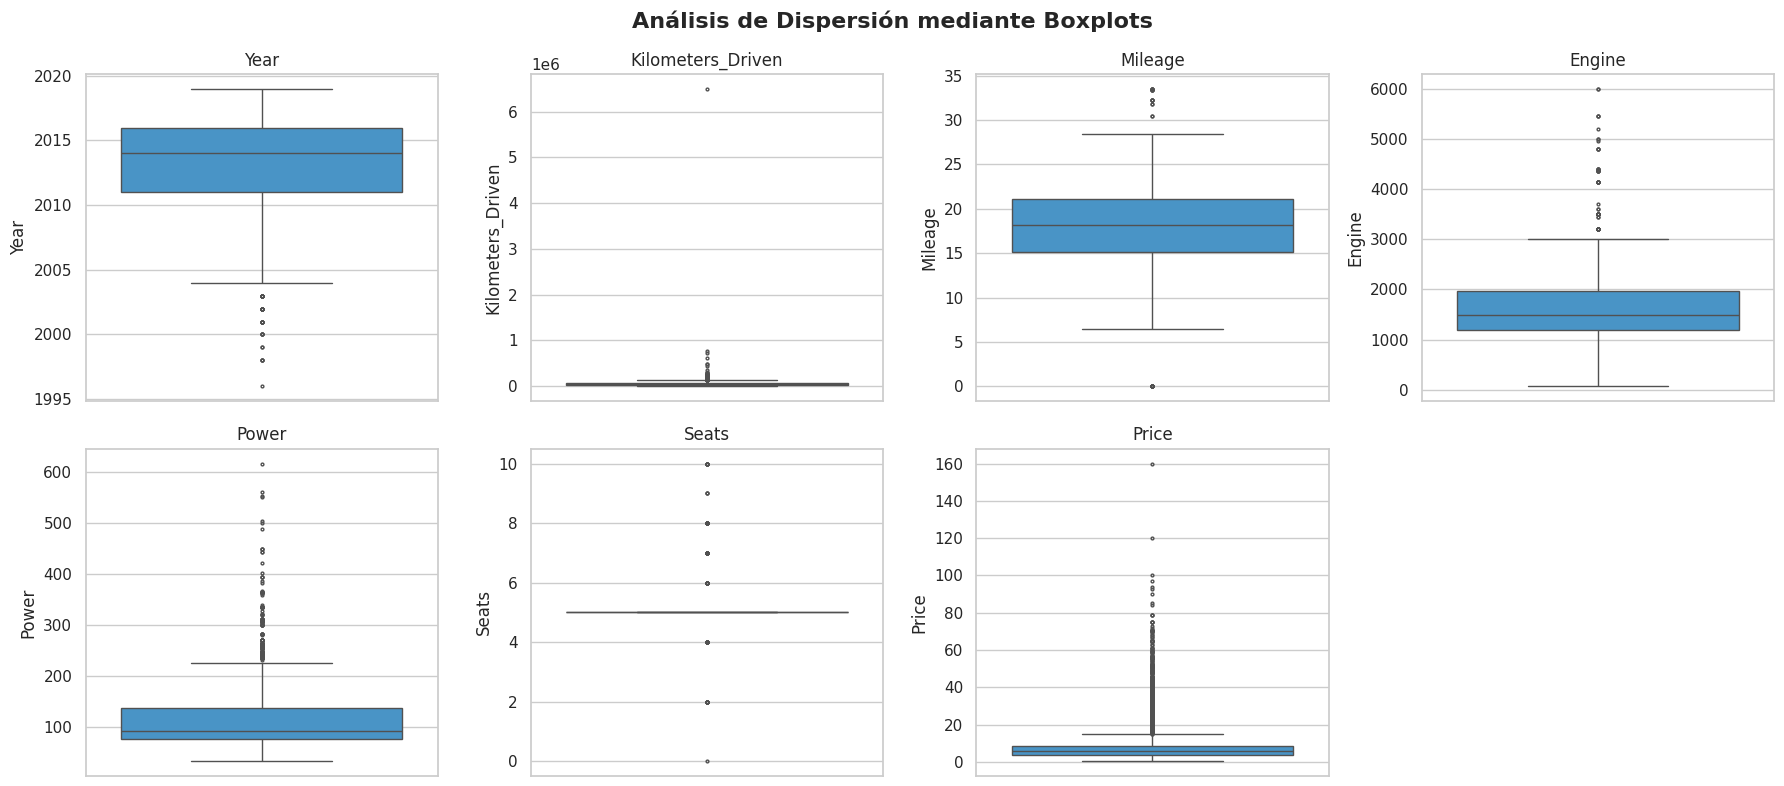

In [4]:
num_cols = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Análisis de Dispersión mediante Boxplots", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db', fliersize=2)
    axes[i].set_title(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Fase 4: Análisis de Balance de Clases
Evaluamos la representatividad de las variables categóricas. Desbalances severos podrían requerir estrategias de **validación estratificada**.

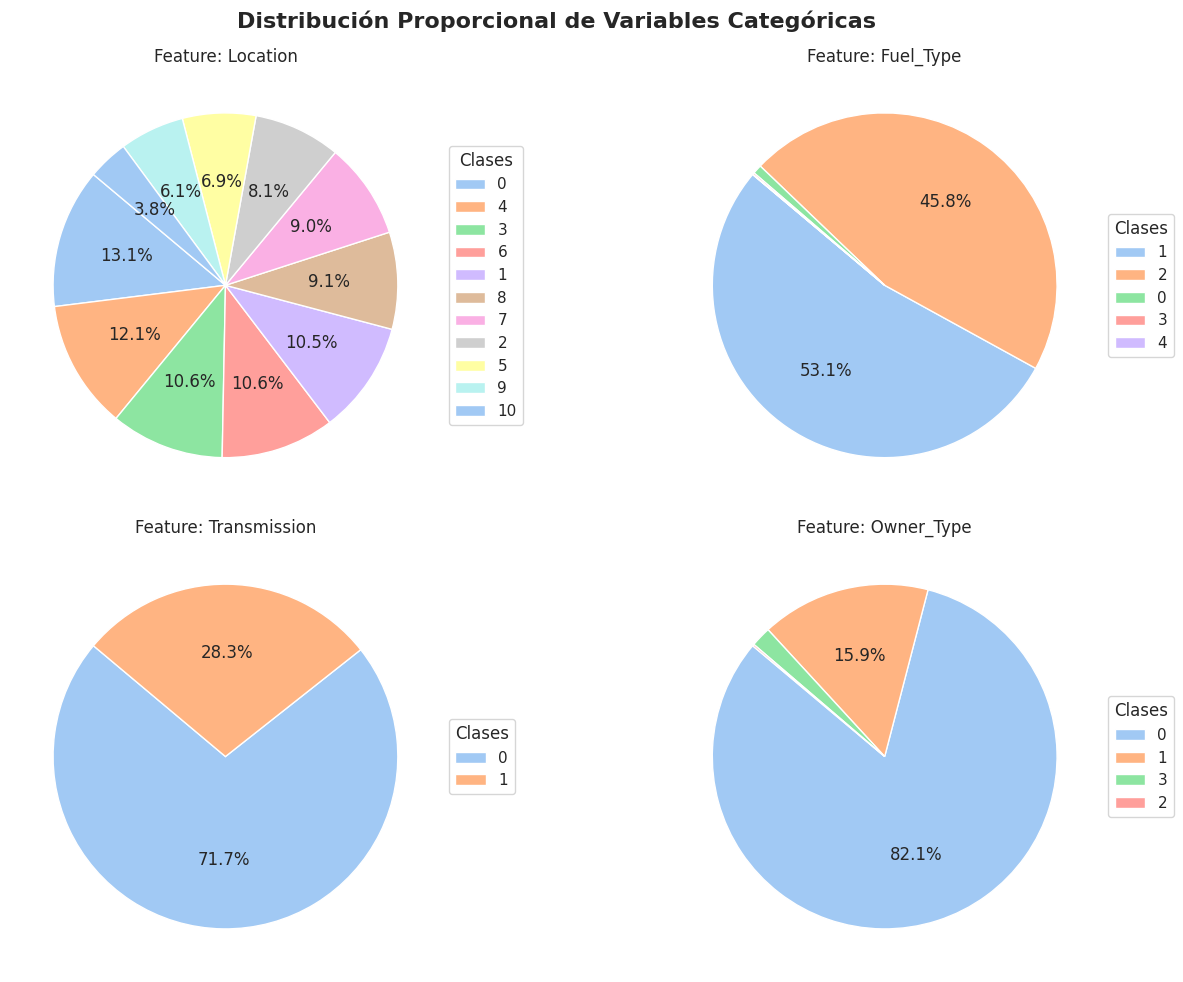

In [5]:
cat_cols = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribución Proporcional de Variables Categóricas", fontsize=16, fontweight='bold')
axes = axes.flatten()

# Función lambda para visualización limpia: oculta etiquetas menores al 2%
fmt = lambda p: f'{p:.1f}%' if p > 2 else ''

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    wedges, texts, autotexts = axes[i].pie(
        counts, autopct=fmt, startangle=140,
        colors=sns.color_palette("pastel"), wedgeprops={'edgecolor': 'white'}
    )
    axes[i].legend(wedges, counts.index, title="Clases", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    axes[i].set_title(f'Feature: {col}')

plt.tight_layout()
plt.show()

## Fase 5: Correlación Bivariada y Feature Importance
Analizamos la relación entre los predictores y la variable objetivo (`Price`). Buscamos linealidad y evaluamos la presencia de **heterocedasticidad**.

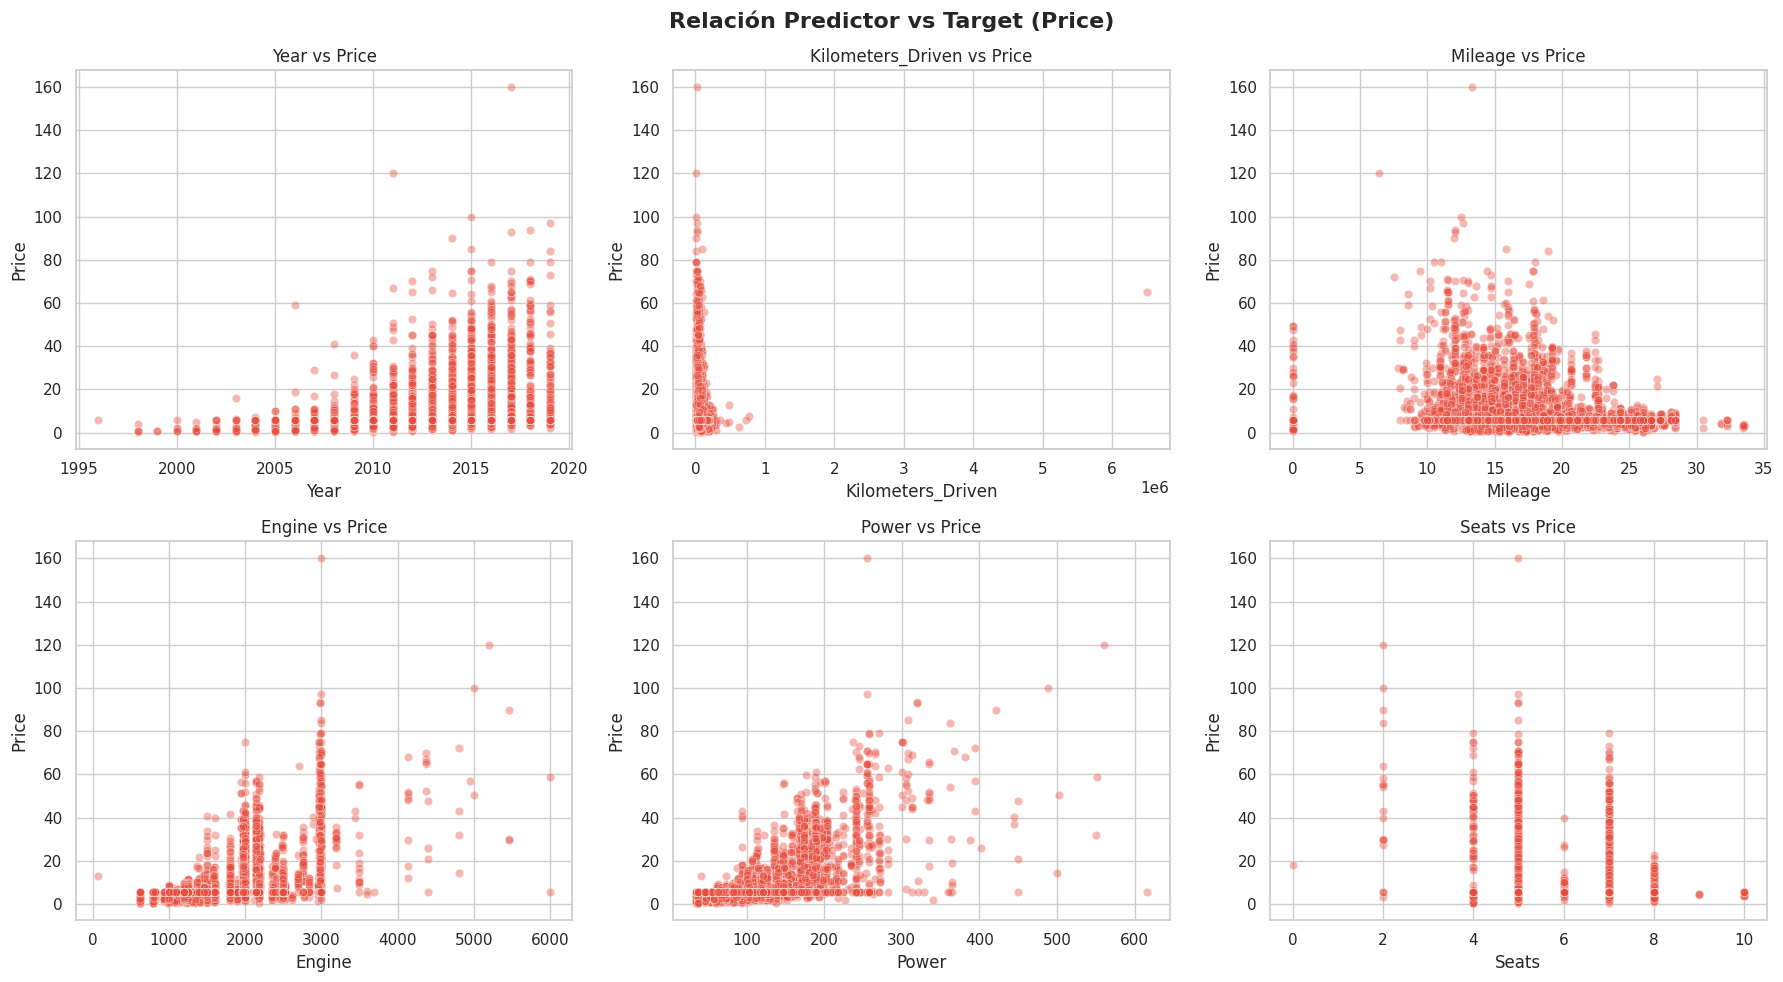

In [6]:
num_features = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Relación Predictor vs Target (Price)", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.scatterplot(x=df[col], y=df['Price'], ax=axes[i], alpha=0.4, color='#e74c3c')
    axes[i].set_title(f'{col} vs Price')

plt.tight_layout()
plt.show()

# ---- Segunda Pre-Entrega ----

##1er paso: Limpieza final del dataset

En esta primera etapa, preparamos los datos eliminando valores nulos, tratando datos atípicos (outliers) y codificando las variables categóricas para que los modelos matemáticos puedan procesarlas.

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

target_col = 'Price'

if target_col in num_cols:
    num_cols.remove(target_col)
if target_col in cat_cols:
    cat_cols.remove(target_col)

imputer_num = SimpleImputer(strategy='median')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

if cat_cols:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

##2do Paso: Particionado 80/20 + Shuffle y Escalado de los Datos

Separamos los datos en un conjunto de entrenamiento (80%) y prueba (20%) con mezcla aleatoria (shuffle=True). Adicionalmente, aplicamos StandardScaler a nuestras variables predictoras (X) para garantizar la estabilidad matemática de algoritmos sensibles a la escala, como el SVR y las Redes Neuronales.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##3er Paso: Aplicación de los Métodos

Definimos tres modelos de regresión: Decision Tree (dt), Random Forest (rf) y Support Vector Regressor (svr).

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

dt = DecisionTreeRegressor(random_state=42)
dt_params = {'max_depth': [None, 5, 10, 15, 20]}

rf = RandomForestRegressor(random_state=42)
rf_params = {'n_estimators': [50, 100, 200, 300]}

svr = SVR()
svr_params = {'kernel': ['linear', 'poly', 'rbf']}

##4to Paso: Cross Validation

Implementamos validación cruzada con K=10 (óptimo para nuestro volumen de datos) usando GridSearchCV para encontrar los mejores hiperparámetros.

In [10]:
from sklearn.model_selection import GridSearchCV

grid_dt = GridSearchCV(estimator=dt, param_grid=dt_params, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
grid_dt.fit(X_train, y_train)

grid_rf = GridSearchCV(estimator=rf, param_grid=rf_params, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)

grid_svr = GridSearchCV(estimator=svr, param_grid=svr_params, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
grid_svr.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=SVR(), n_jobs=-1,
             param_grid={'kernel': ['linear', 'poly', 'rbf']},
             scoring='neg_mean_squared_error')

##Resultados:

 Se observó que el SVR con kernel polinomial presenta una divergencia matemática masiva al intentar predecir valores de precio en lakhs sin escalar la variable objetivo. Esto se documenta visualmente a continuación.

--- MEJORES HIPERPARÁMETROS (TUNING) ---
Mejor Árbol de Decisión (DT): {'max_depth': 5}
Mejor Random Forest (RF): {'n_estimators': 300}
Mejor SVR: {'kernel': 'poly'}
----------------------------------------

--- MÉTRICAS DE RENDIMIENTO (TEST SET) ---
       Modelo      MAE       RMSE    R2 Score
Decision Tree 2.844113   5.620924    0.681037
Random Forest 2.250555   4.862411    0.761313
          SVR 9.604356 263.184850 -698.273079


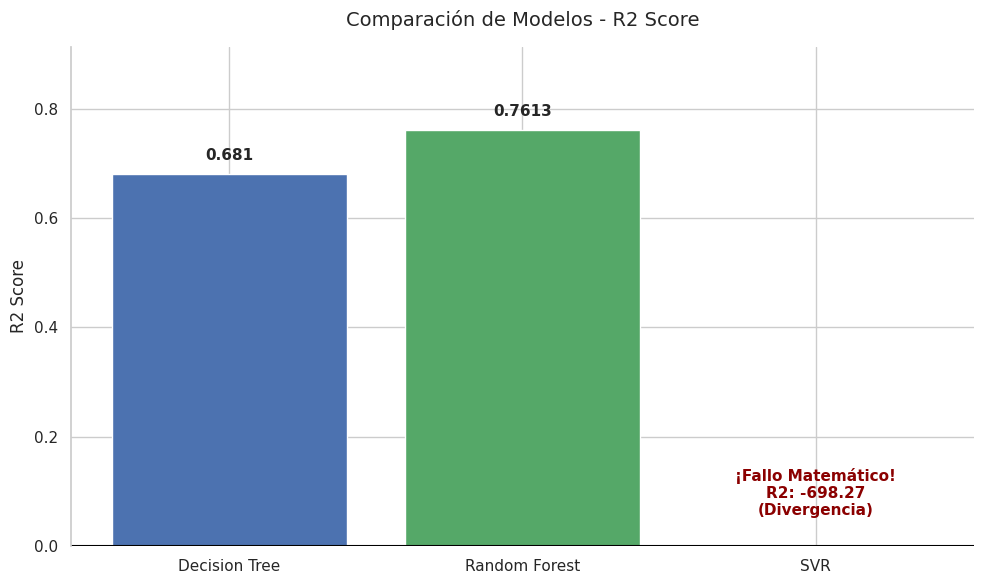

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("--- MEJORES HIPERPARÁMETROS (TUNING) ---")
print(f"Mejor Árbol de Decisión (DT): {grid_dt.best_params_}")
print(f"Mejor Random Forest (RF): {grid_rf.best_params_}")
print(f"Mejor SVR: {grid_svr.best_params_}")
print("-" * 40)

modelos = {
    'Decision Tree': grid_dt.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'SVR': grid_svr.best_estimator_
}

resultados = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo': nombre,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

df_resultados = pd.DataFrame(resultados)
print("\n--- MÉTRICAS DE RENDIMIENTO (TEST SET) ---")
print(df_resultados.to_string(index=False))

plt.figure(figsize=(10, 6))
colores = ['#4C72B0', '#55A868', '#C44E52']
barras = plt.bar(df_resultados['Modelo'], df_resultados['R2 Score'], color=colores)

plt.title('Comparación de Modelos - R2 Score', fontsize=14, pad=15)
plt.ylabel('R2 Score', fontsize=12)

max_y_positivo = df_resultados[df_resultados['R2 Score'] > 0]['R2 Score'].max()

plt.ylim(0, max_y_positivo * 1.2)
plt.axhline(0, color='black', linewidth=1.5)

for barra in barras:
    yval = barra.get_height()
    xval = barra.get_x() + barra.get_width()/2

    if yval > 0:
        plt.text(xval, yval + 0.02, f"{round(yval, 4)}",
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
    else:
        plt.text(xval, 0.05, f"¡Fallo Matemático!\nR2: {round(yval, 2)}\n(Divergencia)",
                 ha='center', va='bottom', fontweight='bold', fontsize=11, color='darkred')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

##5. Deep Learning

Construimos y evaluamos tres arquitecturas de Redes Neuronales Profundas (3, 6 y 10 capas ocultas). Seleccionamos 50 epochs para permitir la convergencia mitigando el riesgo de sobreajuste severo

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

input_dim = X_train.shape[1]

def build_mlp_3_layers():
    model = Sequential()
    model.add(Dense(64, input_dim=input_dim, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_mlp_6_layers():
    model = Sequential()
    model.add(Dense(64, input_dim=input_dim, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_mlp_10_layers():
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    for _ in range(9):
        model.add(Dense(128, activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

mlp_3 = build_mlp_3_layers()
history_3 = mlp_3.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

mlp_6 = build_mlp_6_layers()
history_6 = mlp_6.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

mlp_10 = build_mlp_10_layers()
history_10 = mlp_10.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 58.9396 - mae: 4.0388 - val_loss: 31.4825 - val_mae: 2.8579
Epoch 2/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 32.7684 - mae: 2.9151 - val_loss: 25.8254 - val_mae: 2.6977
Epoch 3/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 31.0541 - mae: 2.7484 - val_loss: 25.2481 - val_mae: 2.6051
Epoch 4/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 29.7988 - mae: 2.6936 - val_loss: 24.6034 - val_mae: 2.5658
Epoch 5/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 28.3213 - mae: 2.5883 - val_loss: 24.4592 - val_mae: 2.5361
Epoch 6/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 28.6579 - mae: 2.6016 - val_loss: 25.9178 - val_mae: 2.6352
Epoch 7/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 28.3169 - mae: 2.6127 - val_loss: 24.9571 - val_mae: 2.5817
Epoch 8/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 27.4995 - mae: 2.5513 - val_loss: 25.5718 - val_mae: 2.5685
Epoch 9/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


182/182 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 50.7479 - mae: 3.7200 - val_loss: 27.9470 - val_mae: 2.7760
Epoch 2/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 34.8200 - mae: 3.0072 - val_loss: 28.9803 - val_mae: 2.8705
Epoch 3/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 35.5896 - mae: 3.0051 - val_loss: 25.9307 - val_mae: 2.6108
Epoch 4/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 32.5781 - mae: 2.7791 - val_loss: 25.2871 - val_mae: 2.6563
Epoch 5/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 31.6519 - mae: 2.7997 - val_loss: 29.0185 - val_mae: 2.7612
Epoch 6/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 31.0860 - mae: 2.7600 - val_loss: 27.2911 - val_mae: 2.6136
Epoch 7/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 29.3247 - mae: 2.6655 - val_loss: 27.0841 - val_mae: 2.7140
Epoch 8/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 28.9465 - mae: 2.6661 - val_loss: 27.7372 - val_mae: 2.6639
Epoch 9/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


182/182 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 52.4154 - mae: 3.6770 - val_loss: 49.6158 - val_mae: 4.2339
Epoch 2/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 33.7734 - mae: 2.8900 - val_loss: 33.2306 - val_mae: 3.1009
Epoch 3/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 32.5428 - mae: 2.7713 - val_loss: 25.9722 - val_mae: 2.5254
Epoch 4/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 33.3353 - mae: 2.8276 - val_loss: 27.1012 - val_mae: 2.6179
Epoch 5/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 31.4282 - mae: 2.8032 - val_loss: 33.6575 - val_mae: 2.9670
Epoch 6/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 29.8393 - mae: 2.6673 - val_loss: 31.4070 - val_mae: 2.8621
Epoch 7/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 31.3485 - mae: 2.8196 - val_loss: 32.3011 - val_mae: 2.8583
Epoch 8/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 31.3074 - mae: 2.7660 - val_loss: 41.5782 - val_mae: 3.1652
Epoch 9/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

##Evaluar rendimiento

In [13]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

modelos_dl = {
    'MLP 3 Capas': mlp_3,
    'MLP 6 Capas': mlp_6,
    'MLP 10 Capas': mlp_10
}

print("--- MÉTRICAS DE RENDIMIENTO (DEEP LEARNING) ---")
for nombre, modelo in modelos_dl.items():
    y_pred_dl = modelo.predict(X_test)
    r2_dl = r2_score(y_test, y_pred_dl)
    rmse_dl = np.sqrt(mean_squared_error(y_test, y_pred_dl))
    print(f"{nombre} -> R2 Score: {r2_dl:.4f} | RMSE: {rmse_dl:.4f}")

--- MÉTRICAS DE RENDIMIENTO (DEEP LEARNING) ---
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MLP 3 Capas -> R2 Score: 0.7218 | RMSE: 5.2494
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MLP 6 Capas -> R2 Score: 0.6644 | RMSE: 5.7658
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MLP 10 Capas -> R2 Score: 0.6358 | RMSE: 6.0059


##Feature Importances

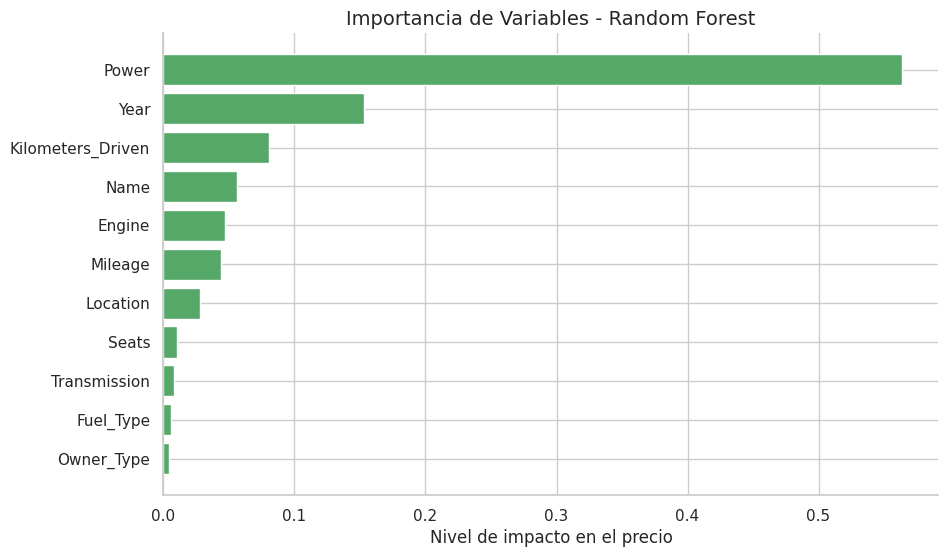

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

best_rf = grid_rf.best_estimator_
importancias = best_rf.feature_importances_
nombres_columnas = X.columns

df_importancias = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_importancias['Variable'], df_importancias['Importancia'], color='#55A868')
plt.title('Importancia de Variables - Random Forest', fontsize=14)
plt.xlabel('Nivel de impacto en el precio', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

# Entrega Final: Aprendizaje de Máquina - UIS

---

## Ítem #1: Pivote a Clasificación y Discretización de la Variable Objetivo
**Estrategia Técnica:** Dado que los algoritmos de aprendizaje no supervisado (Clustering) son inestables al aplicarse directamente sobre un vector de regresión continuo, pivotearemos el problema hacia la **clasificación**.

Para esto, discretizaremos el precio original de los vehículos en tres cuantiles matemáticamente equilibrados, creando tres segmentos de mercado (Clases):
1. **Gama de Entrada** (Vehículos económicos)
2. **Gama Media** (Vehículos estándar)
3. **Gama Alta** (Vehículos premium)

Esta categorización nos servirá como nuestro *Ground Truth* (verdad absoluta) para evaluar cualitativamente si los algoritmos no supervisados logran descubrir esta estructura de mercado por sí solos.

In [29]:
import pandas as pd
import numpy as np

y_clasificacion, bins = pd.qcut(y, q=3, labels=['Gama Entrada', 'Gama Media', 'Gama Alta'], retbins=True)

print("--- DISTRIBUCIÓN DE LAS NUEVAS CLASES (GROUND TRUTH) ---")
print(y_clasificacion.value_counts())
print("\nLímites de corte (Lakhs):", bins)

y_class_num = pd.qcut(y, q=3, labels=[0, 1, 2])

--- DISTRIBUCIÓN DE LAS NUEVAS CLASES (GROUND TRUTH) ---
Price
Gama Entrada    2422
Gama Media      2418
Gama Alta       2413
Name: count, dtype: int64

Límites de corte (Lakhs): [  0.44   4.7    6.7  160.  ]


---

## Ítem 2: Reducción de Dimensionalidad (PCA)
Para cumplir con el requerimiento de visualización en 2D y mitigar la maldición de la dimensionalidad (*Curse of Dimensionality*) que afecta las métricas de distancia en el clustering, aplicaremos **Análisis de Componentes Principales (PCA)**.

El PCA comprimirá todas las características mecánicas y categóricas del vehículo (`X_train` previamente escalado) en **2 componentes ortogonales**, reteniendo la mayor cantidad de varianza posible del dataset original.

In [30]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_global = StandardScaler()
X_escalado = scaler_global.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_escalado)

varianza_explicada = pca.explained_variance_ratio_
print(f"Varianza retenida por Componente 1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza retenida por Componente 2: {varianza_explicada[1]*100:.2f}%")
print(f"Varianza Total Explicada en 2D: {(varianza_explicada[0] + varianza_explicada[1])*100:.2f}%")

df_pca = pd.DataFrame(data=X_pca, columns=['Componente_1', 'Componente_2'])
df_pca['Gama_Real'] = y_class_num.values

Varianza retenida por Componente 1: 26.51%
Varianza retenida por Componente 2: 15.22%
Varianza Total Explicada en 2D: 41.73%


---

## Ítem 3: Modelado No Supervisado (K-Means y DBSCAN)
Aplicaremos los algoritmos sobre el espacio reducido de 2 dimensiones.
* **K-Means:** Forzamos la convergencia a `n_clusters = 3` basándonos en nuestra regla de negocio de mercado.
* **DBSCAN:** Al ser un algoritmo basado en densidad espacial, no recibe un número de clusters estático. Ajustamos los hiperparámetros de vecindad (`eps` y `min_samples`) para que logre agrupar regiones densas y aislar ruido (outliers).

In [32]:
from sklearn.cluster import KMeans, DBSCAN

# 1. K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters_kmeans = kmeans.fit_predict(X_pca)

df_pca['Cluster_KMeans'] = clusters_kmeans

# 2. DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
clusters_dbscan = dbscan.fit_predict(X_pca)

df_pca['Cluster_DBSCAN'] = clusters_dbscan

n_clusters_dbs = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
print(f"Clusters encontrados por DBSCAN: {n_clusters_dbs}")
print(f"Outliers detectados por DBSCAN: {list(clusters_dbscan).count(-1)}")

Clusters encontrados por DBSCAN: 1
Outliers detectados por DBSCAN: 91


---

## Ítem 4: Evaluación Visual y Proyección 2D
A continuación, mapeamos las tres configuraciones en un plano cartesiano compuesto por el **Componente 1** (Eje X) y el **Componente 2** (Eje Y).

Comparamos la distribución real del mercado (Segmentación por cuantiles) contra los patrones matemáticos descubiertos orgánicamente por los algoritmos centroidales y de densidad.

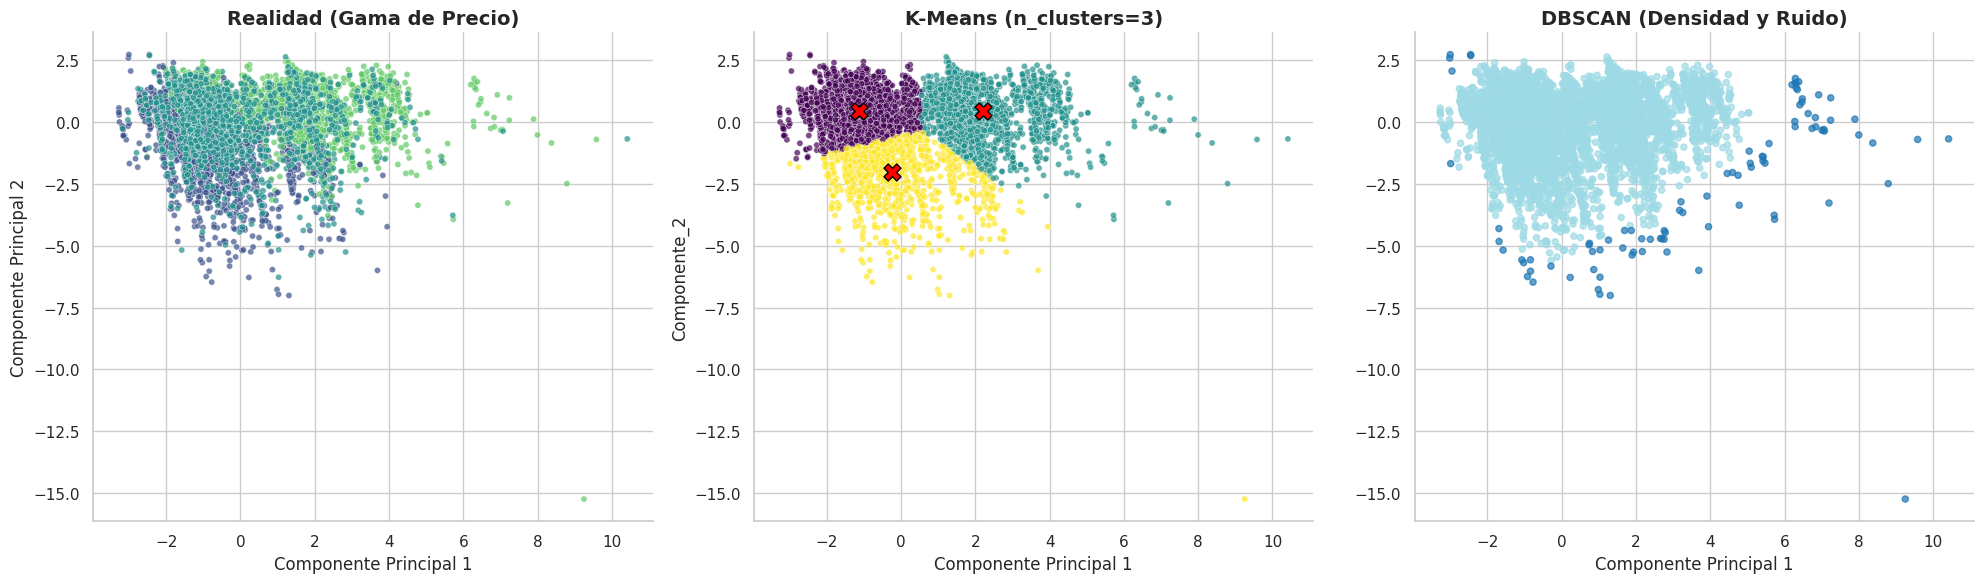

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
paleta = 'viridis'

# 1. Gráfica: Realidad del Mercado
sns.scatterplot(x='Componente_1', y='Componente_2', hue='Gama_Real', data=df_pca, palette=paleta, ax=axes[0], s=20, alpha=0.7)
axes[0].set_title('Realidad (Gama de Precio)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].get_legend().remove()

# 2. Gráfica: Agrupación K-Means
sns.scatterplot(x='Componente_1', y='Componente_2', hue='Cluster_KMeans', data=df_pca, palette=paleta, ax=axes[1], s=20, alpha=0.7)
centroides = kmeans.cluster_centers_
axes[1].scatter(centroides[:, 0], centroides[:, 1], c='red', s=150, marker='X', edgecolors='black', label='Centroides')
axes[1].set_title('K-Means (n_clusters=3)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Componente Principal 1')
axes[1].get_legend().remove()

# 3. Gráfica: Agrupación DBSCAN
paleta_dbscan = sns.color_palette("Set2", as_cmap=True)
sc = axes[2].scatter(df_pca['Componente_1'], df_pca['Componente_2'],
                     c=df_pca['Cluster_DBSCAN'], cmap='tab20', s=20, alpha=0.7)
axes[2].set_title('DBSCAN (Densidad y Ruido)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Componente Principal 1')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---

## Conclusión Técnica - Modelos No Supervisados

1. **Reducción de Dimensionalidad:** El PCA logró comprimir las variables mecánicas del vehículo en un plano 2D. Sin embargo, al observar el mapeo del *Ground Truth*, notamos que los precios altos (Gama Alta) y bajos (Gama de Entrada) no forman esferas perfectas aisladas, sino que existe un solapamiento masivo. Las características del carro dictan tendencia, pero no separan tajantemente los precios en componentes principales.
2. **K-Means:** Al forzar 3 clusters, K-Means dividió el espacio geométricamente trazando fronteras lineales y ubicando sus centroides de forma equidistante. Logra separar sectores del plano, pero ignora por completo la densidad real de los datos, cortando agrupaciones naturales a la mitad.
3. **DBSCAN:** Demuestra ser más orgánico para la distribución de este dataset. En lugar de forzar geometrías rígidas, agrupó el núcleo denso central y detectó la periferia del plano como valores atípicos (outliers espaciales/ruido).